### 설정 및 불러오기

In [1]:
import kagglehub
from google.colab import drive
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, ConcatDataset
import os
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image, ImageOps, ImageDraw
import torch
from tqdm import tqdm
import shutil
import random, math
from torch.utils.data import Dataset, DataLoader
from concurrent.futures import ProcessPoolExecutor
from torch.optim.lr_scheduler import SequentialLR, LambdaLR, CosineAnnealingLR

drive.mount('/content/drive')

print("Downloading PACS dataset via kagglehub...")
path = kagglehub.dataset_download("ma3ple/pacs-dataset")

print("Path to dataset files:", path)

if not os.path.exists('PACS'):
    os.symlink(path, 'PACS')
    print("Created symbolic link: PACS ->", path)

print("Available domains:", os.listdir('PACS'))
current_path = 'PACS'
while 'art_painting' not in [d.lower() for d in os.listdir(current_path)]:
    subdirs = [d for d in os.listdir(current_path) if os.path.isdir(os.path.join(current_path, d))]
    if not subdirs:
        break
    current_path = os.path.join(current_path, subdirs[0])

DATA_ROOT = current_path
print(f"최종 데이터 경로: {DATA_ROOT}")
print(f"발견된 도메인: {os.listdir(DATA_ROOT)}")

Mounted at /content/drive
Using Colab cache for faster access to the 'pacs-dataset' dataset.
Path to dataset files: /kaggle/input/pacs-dataset
Created symbolic link: PACS -> /kaggle/input/pacs-dataset
Available domains: ['kfold']
최종 데이터 경로: PACS/kfold
발견된 도메인: ['cartoon', 'sketch', 'art_painting', 'photo']


### 불러오기 & 하이퍼파라미터

In [ ]:
# --- 랜덤 seed ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- 하이퍼파라미터 ---
BATCH_SIZE    = 32
LR            = 0.001
EPOCHS        = 80
WARMUP_EPOCHS = 3
WEIGHT_DECAY  = 5e-4
IMG_SIZE      = 224
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 설정 ---
data_root = 'PACS'
drive_root = '/content/drive/MyDrive/pacs'
photo_root = 'PACS/kfold/photo'                      
sketch_root = os.path.join(drive_root, 'processed_pacs')  

### 데이터 전처리 후 저장

In [ ]:
def process_and_save_image(img_path, save_path):
  try:
    img_pil = Image.open(img_path).convert("RGB")
    img = np.array(img_pil)
    h, w = img.shape[:2]

    if img.shape[0] < 10 or img.shape[1] < 10:
        img_pil.save(save_path)
        return

    mask = np.zeros(img.shape[:2], np.uint8)
    bgdModel = np.zeros((1, 65), np.float64)
    fgdModel = np.zeros((1, 65), np.float64)

    margin_h = int(h * 0.08)
    margin_w = int(w * 0.08)
    rect = (margin_w, margin_h, w - 2 * margin_w, h - 2 * margin_h)

    cv2.grabCut(img, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

    # 마스크 정리
    mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')

    if np.sum(mask2) < (h * w * 0.03): img_fg = img.copy()
    else:
      img_fg = img * mask2[:, :, np.newaxis]
    img_fg[mask2 == 0] = [255, 255, 255]

    # Canny Edge 적용
    img_gray = cv2.cvtColor(img_fg, cv2.COLOR_RGB2GRAY)
    if category.lower() == 'person': edges = cv2.Canny(img_gray, 40, 100)
    elif category.lower() == 'house': edges = cv2.Canny(img_gray, 40, 100)
    elif category.lower() == 'dog': edges = cv2.Canny(img_gray, 40, 100)
    else: edges = cv2.Canny(img_gray, 30, 100)

    kernel = np.ones((2, 2), np.uint8)
    edges = cv2.dilate(edges, kernel, iterations=1)

    final_img = Image.fromarray(edges)
    final_img.save(save_path)

  except Exception as e:
    print(f"Error processing {img_path}: {e}")

In [ ]:
def reset_folder(path):
    if os.path.exists(path):
        print(f"기존 폴더 삭제 : {path}")
        shutil.rmtree(path)

    os.makedirs(path, exist_ok=True)
    print(f"새 폴더 생성 완료! : {path}")

def task_wrapper(args):
    src, dst = args
    process_and_save_image(src, dst)


scs = []
while True:
  sc = input("전처리할 카테고리 선택(all: 전부, 0: 종료): ")
  if sc == 'all':
    sc = []
    break
  elif sc == '0':
    break
  else: scs.append(sc)

for category in os.listdir(photo_root):
  if len(scs) != 0 and category not in scs: continue

  category_path = os.path.join(photo_root, category)
  save_category_path = os.path.join(sketch_root, category)

  if not os.path.isdir(category_path): continue

  reset_folder(save_category_path)

  files = [f for f in os.listdir(category_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

  tasks = []
  for fname in files:
    src = os.path.join(category_path, fname)
    dst = os.path.join(save_category_path, fname)
    tasks.append((src, dst))

  with ProcessPoolExecutor() as executor:
    list(tqdm(executor.map(task_wrapper, tasks),
      total=len(tasks),
      desc=f"Parallel Processing {category}"))

데이터 변환 시작: PACS/kfold/photo -> /content/drive/MyDrive/pacs/processed_pacs
전처리할 카테고리 선택(all: 전부, 0: 종료): person
전처리할 카테고리 선택(all: 전부, 0: 종료): 0
기존 폴더 삭제 : /content/drive/MyDrive/pacs/processed_pacs/person
새 폴더 생성 완료! : /content/drive/MyDrive/pacs/processed_pacs/person


Parallel Processing person: 100%|██████████| 432/432 [02:28<00:00,  2.90it/s]


모든 변환이 완료되었습니다!


### 데이터 증강 & 로드

In [3]:
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset
import torch.fft as tfft
import torch.nn.functional as F

class MDARDataset(Dataset):
  def __init__(self, photo_root, sketch_root, photo_transform):
    self.photo_ds = datasets.ImageFolder(photo_root)
    self.sketch_root = sketch_root
    self.photo_transform = photo_transform
    self.size = (IMG_SIZE, IMG_SIZE)
    self.person_idx = self.photo_ds.class_to_idx.get('person', -1)

  def generate_stick_figure(self, img_pil):
    output_size = self.size[0]
    scale = random.uniform(0.3, 0.45)
    new_size = int(output_size * scale)
    person_resized = img_pil.resize((new_size, new_size), Image.LANCZOS)

    canvas = Image.new("RGB", (output_size, output_size), (0, 0, 0))
    offset_x = (output_size - new_size) // 2
    offset_y = random.randint(10, 30)
    canvas.paste(person_resized, (offset_x, offset_y))

    draw = ImageDraw.Draw(canvas)
    neck_x, neck_y = offset_x + new_size // 2, offset_y + new_size - 5

    body_len = random.randint(50, 70)
    body_end_x, body_end_y = neck_x, neck_y + body_len
    draw.line([(neck_x, neck_y), (body_end_x, body_end_y)], fill=(255, 255, 255), width=2)

    arm_angle = random.uniform(math.pi/6, math.pi/2)
    arm_len = 40
    for side in [-1, 1]:
        hand_x = neck_x + side * arm_len * math.cos(arm_angle)
        hand_y = neck_y + 10 + arm_len * math.sin(arm_angle)
        draw.line([(neck_x, neck_y + 10), (hand_x, hand_y)], fill=(255, 255, 255), width=2)

    leg_angle = random.uniform(math.pi/6, math.pi/3)
    upper_leg_len, lower_leg_len = 25, 25
    for side in [-1, 1]:
        knee_x = body_end_x + side * upper_leg_len * math.sin(leg_angle)
        knee_y = body_end_y + upper_leg_len * math.cos(leg_angle)
        draw.line([(body_end_x, body_end_y), (knee_x, knee_y)], fill=(255, 255, 255), width=2)
        foot_x = knee_x + side * lower_leg_len * math.sin(leg_angle + random.uniform(-0.2, 0.2))
        foot_y = knee_y + lower_leg_len * math.cos(leg_angle)
        draw.line([(knee_x, knee_y), (foot_x, foot_y)], fill=(255, 255, 255), width=2)

    return canvas

  def get_sobel_edge(self, img_tensor):
    gray = 0.299 * img_tensor[0] + 0.587 * img_tensor[1] + 0.114 * img_tensor[2]
    gray = gray.unsqueeze(0).unsqueeze(0) # [1, 1, H, W]

    kernel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32).view(1, 1, 3, 3)
    kernel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32).view(1, 1, 3, 3)

    grad_x = F.conv2d(gray, kernel_x, padding=1)
    grad_y = F.conv2d(gray, kernel_y, padding=1)
    magnitude = torch.sqrt(grad_x**2 + grad_y**2 + 1e-8)

    return magnitude.repeat(1, 3, 1, 1).squeeze(0)

  def __getitem__(self, index):
    photo_path, label = self.photo_ds.samples[index]
    photo_orig = Image.open(photo_path).convert("RGB")

    rel_path = os.path.relpath(photo_path, self.photo_ds.root)
    sketch_path = os.path.join(self.sketch_root, rel_path)
    canny_orig = Image.open(sketch_path).convert("RGB")

    if label == self.person_idx and random.random() < 0.3:
        photo_orig = self.generate_stick_figure(photo_orig)
        canny_orig = self.generate_stick_figure(canny_orig)

    # 1 Crop 파라미터
    i, j, h, w = transforms.RandomResizedCrop.get_params(photo_orig, scale=(0.7, 1.0), ratio=(0.75, 1.33))
    # 2 horizontal Flip
    do_flip = random.random() > 0.5
    # 3 Rotation
    angle = random.uniform(-15, 15)
    # 4 ramdomPerspective
    startpoints, endpoints = transforms.RandomPerspective.get_params(self.size[0], self.size[1], 0.2)
    do_perspective = random.random() > 0.5

    # 3. 공통 기하 변환 함수
    def apply_geo(img):
      img = TF.resized_crop(img, i, j, h, w, self.size)
      if do_flip: img = TF.hflip(img)
      if do_perspective: img = TF.perspective(img, startpoints, endpoints)
      img = TF.rotate(img, angle, fill=0)
      return img

    photo_raw = self.photo_transform(photo_orig)
    fft_tensor = TF.to_tensor(photo_orig)

    f = tfft.fftn(fft_tensor, dim=(-2, -1))
    fft_tensor = tfft.ifftn(torch.polar(torch.ones_like(f.abs()), f.angle()), dim=(-2, -1)).real
    fft_pil = TF.to_pil_image(fft_tensor)

    sobel_tensor = self.get_sobel_edge(TF.to_tensor(photo_orig))
    sobel_pil = TF.to_pil_image(sobel_tensor)

    fft_tensor = TF.to_tensor(apply_geo(fft_pil))
    photo_tensor = TF.to_tensor(apply_geo(photo_raw))
    canny_tensor = TF.to_tensor(apply_geo(canny_orig))
    sobel_tensor = TF.to_tensor(apply_geo(sobel_pil))

    fft_tensor = (fft_tensor - fft_tensor.min()) / (fft_tensor.max() - fft_tensor.min())
    sobel_tensor = (sobel_tensor - sobel_tensor.min()) / (sobel_tensor.max() - sobel_tensor.min() + 1e-8)
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    return normalize(photo_tensor), normalize(canny_tensor), normalize(fft_tensor), normalize(sobel_tensor), label

  def __len__(self):
    return len(self.photo_ds)

In [4]:
# --- 전처리 (Standard ResNet) ---
train_transform_image = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ColorJitter(brightness=0.4, contrast=0.4),
    transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0)),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3)])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 1.0 - x),
    transforms.Lambda(lambda x: (x > 0.5).float()),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 도메인 분류 ---
all_domain_folders = os.listdir(data_root)
train_domains = ['photo'] #'art_painting', 'cartoon',
test_domain = 'sketch'

In [5]:
# --- 클래스 가중치 계산 ---
class_counts = np.array([len(os.listdir(os.path.join(photo_root, c)))
                          for c in sorted(os.listdir(photo_root))])
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * 7
class_weights = class_weights.to(DEVICE)

# --- 도메인 분류 및 데이터 로더 ---
train_dataset = MDARDataset(photo_root, sketch_root, train_transform_image)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
print(f"Train Domain: photo | Images: {len(train_dataset)}")

test_dataset = datasets.ImageFolder(os.path.join(data_root, 'kfold', 'sketch'), transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"Test Domain: sketch | Images: {len(test_dataset)}")

Train Domain: photo | Images: 1670
Test Domain: sketch | Images: 3929


### 사진 시각화 부분

Checking a 'person' sample (Stick figure might appear with 20% prob)...


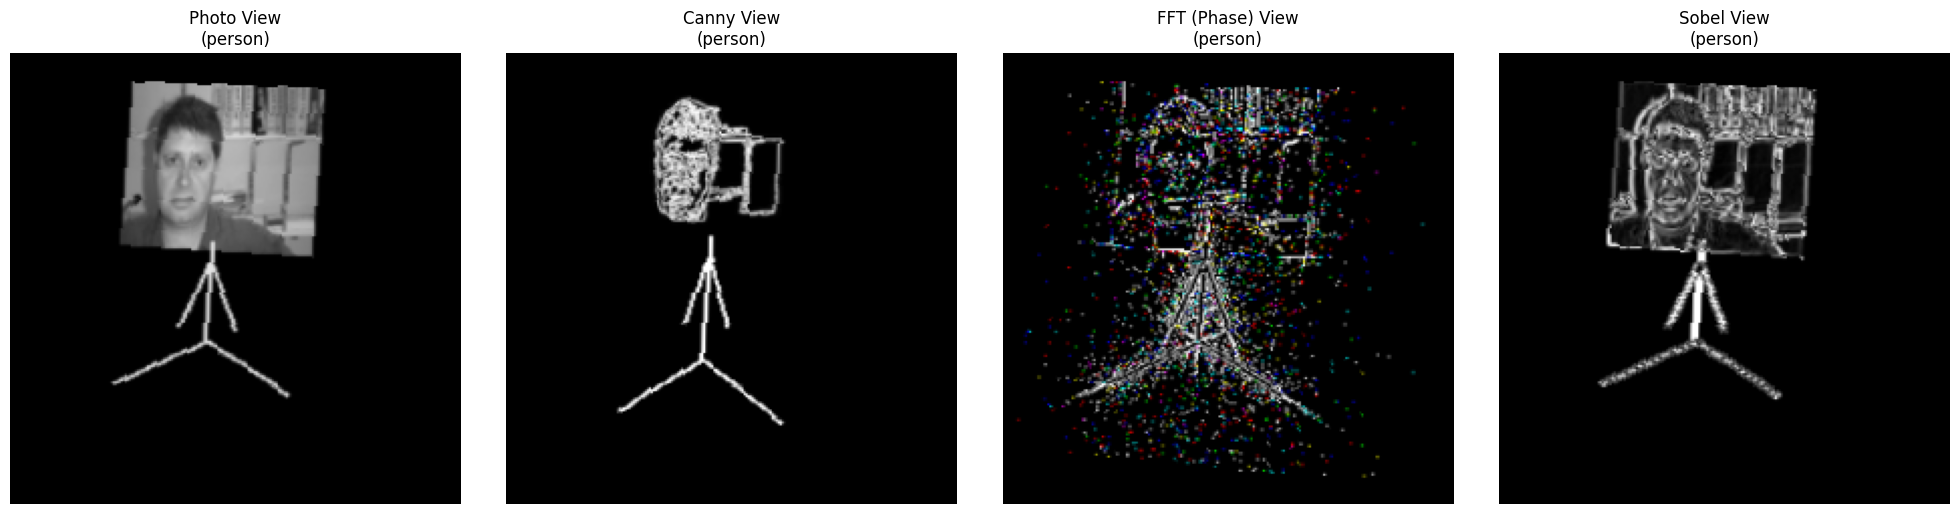

Checking a random sample...


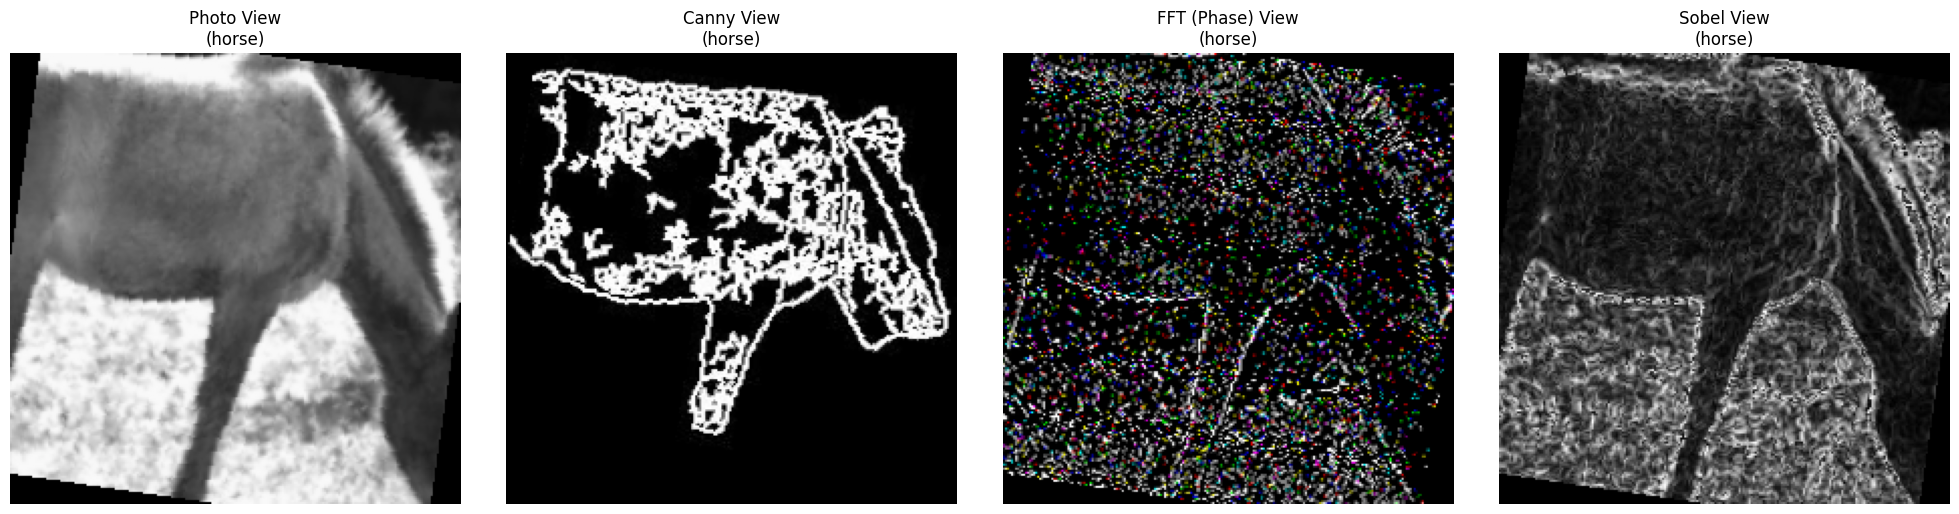

In [ ]:
import matplotlib.pyplot as plt
import torch

def visualize_dataset_sample(dataset, index=None):
    if index is None:
        index = random.randint(0, len(dataset) - 1)

    photo, canny, fft, sobel, label = dataset[index]

    def denormalize(tensor):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        res = tensor * std + mean
        return res.clamp(0, 1).permute(1, 2, 0).numpy()

    class_names = dataset.photo_ds.classes
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    titles = ['Photo View', 'Canny View', 'FFT (Phase) View', 'Sobel View']
    tensors = [photo, canny, fft, sobel]

    for i, (ax, img_tensor, title) in enumerate(zip(axes, tensors, titles)):
        ax.imshow(denormalize(img_tensor))
        ax.set_title(f"{title}\n({class_names[label]})")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

person_indices = [i for i, (path, lbl) in enumerate(train_dataset.photo_ds.samples) if lbl == train_dataset.person_idx]

print(f"Checking a 'person' sample (Stick figure might appear with 20% prob)...")
visualize_dataset_sample(train_dataset, index=person_indices[0])

print(f"Checking a random sample...")
visualize_dataset_sample(train_dataset)

### 레이어 정의

In [6]:
import torch
import torch.nn as nn
from torchvision import models
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn

class IBN(nn.Module):
    def __init__(self, planes):
        super(IBN, self).__init__()
        half1 = int(planes/2)
        self.half = half1
        half2 = planes - half1
        self.IN = nn.InstanceNorm2d(half1, affine=True)
        self.BN = nn.BatchNorm2d(half2)

    def forward(self, x):
        split = torch.split(x, self.half, 1)
        out1 = self.IN(split[0].contiguous())
        out2 = self.BN(split[1].contiguous())
        out = torch.cat((out1, out2), 1)
        return out

class MixStyle(nn.Module):
    def __init__(self, p=0.5, alpha=0.1):
        super().__init__()
        self.p = p
        self.alpha = alpha

    def forward(self, x):
        if not self.training or random.random() > self.p:
            return x

        B = x.size(0)
        perm = torch.randperm(B).to(x.device)

        mu = x.mean(dim=[2, 3], keepdim=True)
        var = x.var(dim=[2, 3], keepdim=True)
        sig = (var + 1e-6).sqrt()

        mu_perm, sig_perm = mu[perm], sig[perm]

        lmda = torch.distributions.Beta(self.alpha, self.alpha).sample((B, 1, 1, 1)).to(x.device)

        mu_mix = mu * lmda + mu_perm * (1 - lmda)
        sig_mix = sig * lmda + sig_perm * (1 - lmda)

        return ((x - mu) / sig) * sig_mix + mu_mix

class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class IBN_SE_BasicBlock(models.resnet.BasicBlock):
    def __init__(self, *args, **kwargs):
        super(IBN_SE_BasicBlock, self).__init__(*args, **kwargs)
        self.bn1 = IBN(self.bn1.num_features)
        self.se = SEBlock(self.conv2.out_channels)

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = self.se(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out

def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

        elif isinstance(m, (nn.BatchNorm2d, nn.InstanceNorm2d)):
            if m.affine:
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        elif isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

class AdvancedResNet18(nn.Module):
    def __init__(self, num_classes=7):
        super(AdvancedResNet18, self).__init__()
        base_model = models.resnet18(weights=None)

        self.conv1 = base_model.conv1
        self.bn1 = base_model.bn1
        self.relu = base_model.relu
        self.maxpool = base_model.maxpool

        self.mixstyle = MixStyle(p=0.5, alpha=0.1)

        self.layer1 = nn.Sequential(IBN_SE_BasicBlock(64, 64), IBN_SE_BasicBlock(64, 64))

        downsample_2 = nn.Sequential(nn.Conv2d(64, 128, 1, 2, bias=False), nn.BatchNorm2d(128))
        self.layer2 = nn.Sequential(IBN_SE_BasicBlock(64, 128, stride=2, downsample=downsample_2), IBN_SE_BasicBlock(128, 128))

        downsample_3 = nn.Sequential(nn.Conv2d(128, 256, 1, 2, bias=False), nn.BatchNorm2d(256))
        self.layer3 = nn.Sequential(IBN_SE_BasicBlock(128, 256, stride=2, downsample=downsample_3), IBN_SE_BasicBlock(256, 256))

        downsample_4 = nn.Sequential(nn.Conv2d(256, 512, 1, 2, bias=False), nn.BatchNorm2d(512))
        self.layer4 = nn.Sequential(IBN_SE_BasicBlock(256, 512, stride=2, downsample=downsample_4), IBN_SE_BasicBlock(512, 512))

        self.avgpool = base_model.avgpool

        self.projector = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 128)
        )
        self.classifier = nn.Linear(512, num_classes)

        initialize_weights(self)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.mixstyle(x)

        x = self.layer2(x)
        x = self.mixstyle(x)

        x = self.layer3(x)
        x = self.layer4(x)
        x = self.mixstyle(x) # 성능 보고 결정

        x = self.avgpool(x)
        feat = torch.flatten(x, 1)

        z = self.projector(feat)
        out = self.classifier(feat)

        return feat, z, out

# 모델 생성
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AdvancedResNet18(num_classes=7).to(DEVICE)

In [7]:
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1, weight=None):
        super(LabelSmoothingCrossEntropy, self).__init__()
        self.smoothing = smoothing
        self.register_buffer('weight', weight)

    def forward(self, pred, target):
        confidence = 1.0 - self.smoothing
        log_probs = torch.nn.functional.log_softmax(pred, dim=-1)

        nll_loss = -log_probs.gather(dim=-1, index=target.unsqueeze(1))
        nll_loss = nll_loss.squeeze(1)

        if self.weight is not None:
          nll_loss = nll_loss * self.weight[target]

        smooth_loss = -log_probs.mean(dim=-1)

        loss = confidence * nll_loss + self.smoothing * smooth_loss
        return loss.mean()

def compute_mdar_loss(z1, z2, lambd=5e-3):
    z1_n = (z1 - z1.mean(0)) / (z1.std(0) + 1e-6)
    z2_n = (z2 - z2.mean(0)) / (z2.std(0) + 1e-6)

    c = torch.mm(z1_n.T, z2_n) / z1.size(0)

    on_diag = torch.diagonal(c).add_(-1).pow_(2).sum()
    off_diag = (c - torch.diag(torch.diagonal(c))).pow_(2).sum()

    return on_diag + lambd * off_diag

def update_prototypes_and_loss(feat, labels, prototypes, proto_momentum=0.9, temperature=0.07):
    with torch.no_grad():
        for c in range(prototypes.shape[0]):
            mask = (labels == c)
            if mask.sum() > 0:
                class_feat = F.normalize(feat[mask].detach().mean(0), dim=0)
                if prototypes[c].abs().sum() < 1e-8:
                    prototypes[c] = class_feat
                else:
                    prototypes[c] = proto_momentum * prototypes[c] + (1 - proto_momentum) * class_feat

    feat_norm  = F.normalize(feat, dim=1)
    proto_norm = F.normalize(prototypes, dim=1)

    sim = torch.mm(feat_norm, proto_norm.t()) / temperature
    return F.cross_entropy(sim, labels)

In [8]:
criterion = LabelSmoothingCrossEntropy(smoothing=0.1, weight=class_weights)
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=WEIGHT_DECAY)

warmup_lambda = lambda epoch: (epoch + 1) / WARMUP_EPOCHS
warmup_scheduler = LambdaLR(optimizer, lr_lambda=warmup_lambda)
main_scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS, eta_min=1e-5)

scheduler = SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, main_scheduler],
    milestones=[WARMUP_EPOCHS]
)

swa_scheduler = SWALR(optimizer, swa_lr=0.001)

In [9]:
import torch.fft as fft
import random

# def prob_fourier_mixup(img, alpha_max=1.0):
#     fea = fft.fftn(img, dim=(-2, -1))
#     fea_amp, fea_phs = fea.abs(), fea.angle()

#     idx = torch.randperm(img.size(0))
#     fea_amp_target = fea_amp[idx]

#     lam = random.uniform(0, alpha_max)

#     mixed_amp = (1 - lam) * fea_amp + lam * fea_amp_target

#     mixed_fea = torch.polar(mixed_amp, fea_phs)
#     mixed_img = fft.ifftn(mixed_fea, dim=(-2, -1)).real

#     return mixed_img

def prob_fourier_mixup(img, alpha_max=1.0, ratio=0.1):
    B, C, H, W = img.shape
    device = img.device

    fea = fft.fftn(img, dim=(-2, -1))
    fea = fft.fftshift(fea, dim=(-2, -1))
    fea_amp, fea_phs = fea.abs(), fea.angle()

    idx = torch.randperm(B).to(device)
    fea_amp_target = fea_amp[idx]

    mask = torch.zeros((H, W), device=device)
    rh, rw = int(H * ratio), int(W * ratio)
    mask[H//2 - rh//2 : H//2 + rh//2, W//2 - rw//2 : W//2 + rw//2] = 1
    mask = mask.view(1, 1, H, W)

    lam = random.uniform(0, alpha_max)

    mixed_amp = fea_amp.clone()
    mixed_amp = (1 - lam * mask) * fea_amp + (lam * mask) * fea_amp_target

    mixed_fea = torch.polar(mixed_amp, fea_phs)
    mixed_fea = fft.ifftshift(mixed_fea, dim=(-2, -1))
    mixed_img = fft.ifftn(mixed_fea, dim=(-2, -1)).real

    mixed_img = torch.clamp(mixed_img, 0, 1)

    return mixed_img

def compute_subcon_loss(z_list, labels, temperature=0.07):
    features = torch.cat(z_list, dim=0)
    features = F.normalize(features, dim=1)

    targets = torch.cat([labels for _ in range(len(z_list))], dim=0)

    logits = torch.matmul(features, features.T) / temperature

    mask = torch.eq(targets.unsqueeze(1), targets.unsqueeze(0)).float().to(z_list[0].device)
    logits_mask = torch.scatter(
        torch.ones_like(mask), 1,
        torch.arange(targets.shape[0]).view(-1, 1).to(z_list[0].device), 0
    )
    mask = mask * logits_mask


    exp_logits = torch.exp(logits) * logits_mask
    log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-6)

    mean_log_prob_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-6)
    loss = -mean_log_prob_pos.mean()

    return loss

In [10]:
prototypes = torch.zeros(7, 512).to(DEVICE)
proto_momentum = 0.9

def train_one_epoch(epoch):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    lambda_mdar = min(0.8, 0.1 + epoch / 40)

    for i, (pimgs, bimgs, fimgs, simgs, labels) in enumerate(train_loader):
        pimgs, bimgs, fimgs, simgs, labels = pimgs.to(DEVICE), bimgs.to(DEVICE), fimgs.to(DEVICE), simgs.to(DEVICE), labels.to(DEVICE)
        pfimgs = prob_fourier_mixup(pimgs, alpha_max=0.5)

        lam = np.random.beta(0.4, 0.4) # 0.2 정도로 약하게 설정
        index = torch.randperm(pimgs.size(0)).to(DEVICE)
        mixed_pfimgs = lam * pfimgs + (1 - lam) * pfimgs[index]
        labels_b = labels[index]

        optimizer.zero_grad()

        feat1, z1, out1 = model(pimgs)
        feat2, z2, out2 = model(bimgs)
        feat3, z3, out3 = model(fimgs)
        feat4, z4, out4 = model(pfimgs)
        feat5, z5, out5 = model(simgs)
        feat6, z6, out6 = model(mixed_pfimgs)

        loss_cls_standard = (criterion(out1, labels) + criterion(out2, labels) +
                             criterion(out3, labels) + criterion(out4, labels) +
                             criterion(out5, labels)) / 5
        loss_cls_mixup = lam * criterion(out6, labels) + (1 - lam) * criterion(out6, labels_b)
        loss_cls = (loss_cls_standard + loss_cls_mixup) / 2

        l12 = compute_mdar_loss(feat1, feat2)
        l13 = compute_mdar_loss(feat1, feat3)
        l14 = compute_mdar_loss(feat1, feat4)
        l15 = compute_mdar_loss(feat1, feat5)
        l23 = compute_mdar_loss(feat2, feat3)
        l24 = compute_mdar_loss(feat2, feat4)
        l25 = compute_mdar_loss(feat2, feat5)
        l34 = compute_mdar_loss(feat3, feat4)
        l35 = compute_mdar_loss(feat3, feat5)
        l45 = compute_mdar_loss(feat4, feat5)
        loss_mdar = (l12 + l13 + l14 + l15 + l23 + l24 + l25 + l34 + l35 + l45) / 10
        loss_proto = update_prototypes_and_loss(feat2, labels, prototypes)
        loss_subcon = compute_subcon_loss([z1, z2, z3, z4, z5], labels)
        total_loss = loss_cls + (lambda_mdar * loss_mdar) + (0.1 * loss_proto) + (0.05 * loss_subcon)

        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item()
        # 정확도는 sketch에 가장 가까운 canny 뷰(out2) 기준으로 측정
        _, predicted = out2.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    print(f"Epoch {epoch+1}/{EPOCHS} | LR: {current_lr:.6f} | Loss: {running_loss/len(train_loader):.4f} | Train(canny): {100.*correct/total:.2f}% | ", end='')

def evaluate_ood(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            _, _, out1 = model(imgs)
            prob1 = F.softmax(out1, dim=1)

            _, _, out2 = model(TF.hflip(imgs))
            prob2 = F.softmax(out2, dim=1)
            avg_probs = (prob1 + prob2) / 2

            preds = avg_probs.argmax(dim=1)

            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    acc = 100. * correct / total
    print(f"Test: {acc:.2f}%")
    return acc

### 학습

In [11]:
# --- 실행 ---
print("Challenge Start!")
state_dict = torch.load('/content/drive/MyDrive/pacs/best_model_test12.pth')
model.load_state_dict(state_dict)
best_val_acc = 0.0

for epoch in range(EPOCHS):
    train_one_epoch(epoch)

    val_acc = evaluate_ood(model, test_loader)

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save(model.state_dict(), os.path.join(drive_root, 'test13'+str(epoch+1)+'pacs_model.pth'))
      print(f"Epoch {epoch+1}: new best accuracy {val_acc:.2f}")



Challenge Start!
Epoch 1/80 | LR: 0.006667 | Loss: 21.7575 | Train(canny): 66.77% | Test: 62.64%
Epoch 1: new best accuracy 62.64
Epoch 2/80 | LR: 0.010000 | Loss: 29.2557 | Train(canny): 57.01% | Test: 53.53%
Epoch 3/80 | LR: 0.010000 | Loss: 35.9828 | Train(canny): 61.14% | Test: 40.57%
Epoch 4/80 | LR: 0.009996 | Loss: 41.1792 | Train(canny): 59.82% | Test: 48.28%
Epoch 5/80 | LR: 0.009983 | Loss: 46.1720 | Train(canny): 56.65% | Test: 54.39%
Epoch 6/80 | LR: 0.009963 | Loss: 55.7778 | Train(canny): 55.63% | Test: 34.87%
Epoch 7/80 | LR: 0.009934 | Loss: 63.7213 | Train(canny): 53.47% | Test: 18.73%


KeyboardInterrupt: 

### 평가

In [12]:
def evaluate_ood_plus(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            B = imgs.size(0)

            _, _, out1 = model(imgs)
            prob1 = F.softmax(out1, dim=1)
            conf1, _ = prob1.max(dim=1, keepdim=True)

            _, _, out2 = model(TF.hflip(imgs))
            prob2 = F.softmax(out2, dim=1)
            conf2, _ = prob2.max(dim=1, keepdim=True)

            scaled_img = TF.resize(imgs, [int(IMG_SIZE * 1.1), int(IMG_SIZE * 1.1)])
            crop_img = TF.center_crop(scaled_img, [IMG_SIZE, IMG_SIZE])
            _, _, out3 = model(crop_img)
            prob3 = F.softmax(out3, dim=1)
            conf3, _ = prob3.max(dim=1, keepdim=True)

            weighted_probs = (prob1 * conf1) + (prob2 * conf2) + (prob3 * conf3)
            total_conf = conf1 + conf2 + conf3 + 1e-6

            final_probs = weighted_probs / total_conf
            preds = final_probs.argmax(dim=1)

            correct += preds.eq(labels).sum().item()
            total += B

    acc = 100. * correct / total
    print(f"Test: {acc:.2f}%")
    return acc

model.load_state_dict(torch.load('/content/drive/MyDrive/pacs/best_model_test13.pth'))

print(evaluate_ood_plus(model, test_loader))
print(evaluate_ood(model, test_loader))

Test: 63.35%
63.3494527869687
Test: 62.64%
62.63680325782642


### 이전 best model 불러오기

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn

# --- IBN ---
class PIBN(nn.Module):
    def __init__(self, planes):
        super(PIBN, self).__init__()
        self.half = int(planes / 2)
        self.IN = nn.InstanceNorm2d(self.half, affine=True)
        self.BN = nn.BatchNorm2d(planes - self.half)

    def forward(self, x):
        split = torch.split(x, self.half, 1)

        out1 = self.IN(split[0].contiguous())
        out2 = self.BN(split[1].contiguous())

        out = torch.cat((out1, out2), 1)
        return out

class PSEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super(PSEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class PIBN_SE_BasicBlock(models.resnet.BasicBlock):
    def __init__(self, *args, **kwargs):
        super(PIBN_SE_BasicBlock, self).__init__(*args, **kwargs)
        self.bn1 = PIBN(self.bn1.num_features)
        self.se = PSEBlock(self.conv2.out_channels)

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = self.se(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out

def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

        elif isinstance(m, (nn.BatchNorm2d, nn.InstanceNorm2d)):
            if m.affine:
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        elif isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

def get_advanced_resnet18(device):
    model = models.resnet18(weights=None)

    model.layer1 = nn.Sequential(
        PIBN_SE_BasicBlock(64, 64),
        PIBN_SE_BasicBlock(64, 64)
    )

    downsample_2 = nn.Sequential(
        nn.Conv2d(64, 128, kernel_size=1, stride=2, bias=False),
        nn.BatchNorm2d(128),
    )
    model.layer2 = nn.Sequential(
        PIBN_SE_BasicBlock(64, 128, stride=2, downsample=downsample_2),
        PIBN_SE_BasicBlock(128, 128)
    )

    downsample_3 = nn.Sequential(
        nn.Conv2d(128, 256, kernel_size=1, stride=2, bias=False),
        nn.BatchNorm2d(256),
    )
    model.layer3 = nn.Sequential(
        PIBN_SE_BasicBlock(128, 256, stride=2, downsample=downsample_3),
        PIBN_SE_BasicBlock(256, 256)
    )

    downsample_4 = nn.Sequential(
        nn.Conv2d(256, 512, kernel_size=1, stride=2, bias=False),
        nn.BatchNorm2d(512),
    )
    model.layer4 = nn.Sequential(
        PIBN_SE_BasicBlock(256, 512, stride=2, downsample=downsample_4),
        PIBN_SE_BasicBlock(512, 512)
    )

    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    nn.init.kaiming_normal_(model.conv1.weight, mode='fan_out', nonlinearity='relu')

    model.fc = nn.Linear(512, 7)

    initialize_weights(model)
    return model.to(device)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
prev_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5), # new
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9), # new
    transforms.RandomRotation(15, fill=255),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.1), value=-1) # new
])

prev_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 1.0 - x),
    transforms.Lambda(lambda x: (x > 0.5).float()),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

prev_train_dataset = datasets.ImageFolder(sketch_root, transform=prev_train_transform)
prev_train_loader = DataLoader(prev_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
print(f"Train Domain: photo | Images: {len(train_dataset)}")

prev_test_dataset = datasets.ImageFolder(os.path.join(data_root, 'kfold', 'sketch'), transform=prev_test_transform)
prev_test_loader = DataLoader(prev_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Train Domain: photo | Images: 1670


In [ ]:
def prev_evaluate_best_model_with_tta(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            out1 = model(imgs)

            out2 = model(TF.hflip(imgs))

            scaled_img = TF.resize(imgs, [int(IMG_SIZE * 1.1), int(IMG_SIZE * 1.1)])
            crop_img = TF.center_crop(scaled_img, [IMG_SIZE, IMG_SIZE])
            out3 = model(crop_img)

            bright_img = TF.adjust_brightness(imgs, 1.2)
            out4 = model(bright_img)

            avg_probs = (F.softmax(out1, dim=1) +
                         F.softmax(out2, dim=1) +
                         F.softmax(out3, dim=1) +
                         F.softmax(out4, dim=1)) / 4

            preds = avg_probs.argmax(dim=1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    return 100. * correct / total

In [19]:
model1 = AdvancedResNet18(num_classes=7).to(DEVICE)
model1.load_state_dict(torch.load('/content/drive/MyDrive/pacs/best_model_test13.pth'))

prev_model1 = get_advanced_resnet18(DEVICE)
prev_model1.load_state_dict(torch.load('/content/drive/MyDrive/pacs/best_model_test1.pth'))

prev_model2 = get_advanced_resnet18(DEVICE)
prev_model2.load_state_dict(torch.load('/content/drive/MyDrive/pacs/swa_best_model1.pth'))

<All keys matched successfully>

In [17]:
def prev_evaluate_ood(model, test_loader):
  model.eval()
  correct = 0
  total = 0

  with torch.no_grad():
    for imgs, labels in test_loader:
      imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

      out1 = model(imgs)
      prob1 = F.softmax(out1, dim=1)

      out2 = model(TF.hflip(imgs))
      prob2 = F.softmax(out2, dim=1)

      avg_probs = (prob1 + prob2) / 2

      preds = avg_probs.argmax(dim=1)

      correct += preds.eq(labels).sum().item()
      total += labels.size(0)

  acc = 100. * correct / total
  print(f"Test: {acc:.2f}%")
  return acc

In [31]:
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF

def evaluate_multi_loader_ensemble(model_ace, ace_loader, model_sub1, model_sub2, sub_loader, device):
    model_ace.eval()
    model_sub1.eval()
    model_sub2.eval()

    correct = 0
    total = 0

    # 가중치 설정 (56.6% 모델에 더 비중을 둠)
    W_ace = 0.65
    W_sub = 0.35

    print(f"🚀 Multi-Loader Ensemble Start!")

    with torch.no_grad():
        # 두 로더를 zip으로 묶어 동시에 배치를 꺼냅니다.
        # batch_ace: model1용 (RGB/4-TTA), batch_sub: prev모델용 (Gray/2-TTA)
        for (imgs_ace, labels), (imgs_sub, _) in zip(ace_loader, sub_loader):
            imgs_ace, imgs_sub, labels = imgs_ace.to(device), imgs_sub.to(device), labels.to(device)
            B = imgs_ace.size(0)

            # --- [1] model1 (Ace): ace_loader 이미지 사용 + 4-TTA ---
            def get_4tta_prob(model, x):
                # 팀장님 모델 출력 형식(tuple)에 맞춰 [2]번 인덱스(logits) 사용
                out_orig = model(x)[2]
                out_flip = model(TF.hflip(x))[2]

                s_img = TF.center_crop(TF.resize(x, [int(224*1.1)]*2), [224]*2)
                out_crop = model(s_img)[2]

                out_bright = model(TF.adjust_brightness(x, 1.2))[2]

                # Temperature 1.4 적용하여 앙상블 부드럽게
                T = 1.0
                return (torch.softmax(out_orig/T, 1) + torch.softmax(out_flip/T, 1) +
                        torch.softmax(out_crop/T, 1) + torch.softmax(out_bright/T, 1)) / 4

            prob_ace = get_4tta_prob(model_ace, imgs_ace)

            # --- [2] prev_best (Sub): sub_loader 이미지 사용 + 2-TTA ---
            def get_2tta_prob(model, x):
                # model2가 만약 단일 텐서를 반환한다면 체크 필요
                out = model(x)
                o = out[2] if isinstance(out, tuple) else out

                out_f = model(TF.hflip(x))
                of = out_f[2] if isinstance(out_f, tuple) else out_f

                T = 1.4
                return (torch.softmax(o/T, 1) + torch.softmax(of/T, 1)) / 2

            prob_sub1 = get_2tta_prob(model_sub1, imgs_sub)
            prob_sub2 = get_2tta_prob(model_sub2, imgs_sub)
            prob_sub_total = (prob_sub1*0.6 + prob_sub2*0.4)

            # --- [3] 최종 결합 ---
            final_prob = (prob_ace * W_ace) + (prob_sub_total * W_sub)

            preds = final_prob.argmax(dim=1)
            correct += preds.eq(labels).sum().item()
            total += B

    acc = 100. * correct / total
    print("-" * 30)
    print(f"🔥 Final 60% Challenge Acc: {acc:.2f}%")
    print("-" * 30)
    return acc

# 실행 (로더 명칭을 팀장님 변수명에 맞게 확인해주세요)
final_score = evaluate_multi_loader_ensemble(
    model1, test_loader,           # 에이스 (RGB)
    prev_model1, prev_model2, prev_test_loader, # 서브 (Gray)
    device=DEVICE
)

🚀 Multi-Loader Ensemble Start!
------------------------------
🔥 Final 60% Challenge Acc: 64.52%
------------------------------
